In [1]:
# Python 3.12.3
# Install necessary packages
# !pip install pandas
# !pip install numpy
# !pip install nltk
# !pip install beautifulsoup4
# !pip install emoji
# !pip install contractions
# !pip install vaderSentiment
# !pip install tensorflow
# !pip install scikit-learn
# !pip install matplotlib
# !pip install seaborn
# !pip install transformers
# !pip install datasets
# !pip install torch
# !pip install imbalanced-learn

In [2]:
# Importing necessary libraries for text preprocessing, data handling, and visualization
import pandas as pd  # For handling data in DataFrame structures, making it easier to manipulate and analyze data
import numpy as np  # For numerical operations, especially for handling arrays and matrices efficiently
import re  # For regular expressions, which are used to find and manipulate specific patterns in text data
import contractions # To expand contractions into their full form (example "don't" becomes "do not"), crucial for accurate text analysis
import emoji  # For converting emojis into text descriptions, making them interpretable for sentiment analysis
from bs4 import BeautifulSoup  # For parsing and cleaning HTML tags from text, common in web-scraped data
import nltk  # For natural language processing tasks
import string  # For string operations like removing punctuation from text
from nltk.corpus import stopwords  # For removing common stopwords (e.g., 'the', 'and') that do not contribute much to sentiment
from nltk.tokenize import word_tokenize  # For splitting text into individual words (tokenization)
from nltk.stem import WordNetLemmatizer
from nltk.stem.porter import PorterStemmer

# Visualization libraries for confusion matrix and other plots
import matplotlib.pyplot as plt  # For plotting charts and visualizing data
import seaborn as sns  # For creating more visually appealing plots, especially heatmaps for confusion matrices

# Machine Learning and Model Evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

# TensorFlow and Keras for Deep Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# Huggingface Transformers for DistilBERT
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification, Trainer, TrainingArguments
from datasets import Dataset

# PyTorch for GPU usage and deep learning
import torch

# Ensure reproducibility
import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


In [4]:
# Load the training and test datasets
train_data = pd.read_parquet(r"C:\Users\flori\Documents\Uni\Uni\2024\SoSe24\DELTA\Element_3\btc_tweets_train.parquet.gzip")
test_data = pd.read_parquet(r"C:\Users\flori\Documents\Uni\Uni\2024\SoSe24\DELTA\Element_3\btc_tweets_test.parquet.gzip")


In [101]:
# Explore the data. 
# Understanding the data is crucial before any processing. 
# This includes checking for missing values, data types, and class distribution.
print("Training Data Info:")
print(train_data.info())
print("\nTraining Data Distribution:")
print(train_data['sentiment'].value_counts())

print("\nTest Data Info:")
print(test_data.info())

Training Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 1500 entries, 1641579121972236290 to 1641861677149822976
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   hashtags          1500 non-null   object
 1   content           1500 non-null   object
 2   username          1500 non-null   object
 3   user_displayname  1500 non-null   object
 4   sentiment         1500 non-null   bool  
 5   tweet_length      1500 non-null   int64 
dtypes: bool(1), int64(1), object(4)
memory usage: 71.8+ KB
None

Training Data Distribution:
sentiment
True     1220
False     280
Name: count, dtype: int64

Test Data Info:
<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 1641861708246552576 to 1641953216999968769
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   hashtags          500 non-null    object
 1   content           500 non-n

In [15]:
# Exploring the first few rows to understand the data structure
print("\nSample of the training data:")
train_data.head()


Sample of the training data:


,hashtags,content,username,user_displayname,sentiment,tweet_length
tweet ID,,,,,,
1641579121972236290,"[Bitcoin, Bitcoin, BTC, Bitcoin, BTC, SHIB, HO...","$Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏...",BezosCrypto,SHIB Bezos,True,29
1641579176171016194,"[Bitcoin, bitcoinordinals, crypto]",Alright I have my rares. Who else is grabbing ...,spartantc81,SpartanTC,True,28
1641579486071390208,"[BTC, SHIB, HOGE, SAITAMA, BNB, DOGE, ETH, Bab...","Bitcoin (BTC) Targets Over $100,000 as This Im...",BezosCrypto,SHIB Bezos,True,36
1641579537103302656,[BTC],📢 Xverse Web-based pool is live:\n\n•Update @x...,godfred_xcuz,Algorithm.btc,True,34
1641579588399804418,[Bitcoin],"Yesterday, a Bitcoin projection was displayed ...",goddess81oo,she is lucky,True,18


In [16]:
# Explore the  train data
print("Training Data Summary:")
train_data.describe(include='all')


Training Data Summary:


,hashtags,content,username,user_displayname,sentiment,tweet_length
count,1500,1500,1500,1500,1500,1500.000000
unique,945,1500,1012,1012,2,NaN
top,[Bitcoin],"$Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏...",BezosCrypto,SHIB Bezos,True,NaN
freq,384,1,41,41,1220,NaN
mean,NaN,NaN,NaN,NaN,NaN,27.524667
std,NaN,NaN,NaN,NaN,NaN,13.363649
min,NaN,NaN,NaN,NaN,NaN,3.000000
25%,NaN,NaN,NaN,NaN,NaN,16.000000
50%,NaN,NaN,NaN,NaN,NaN,28.000000
75%,NaN,NaN,NaN,NaN,NaN,39.000000


In [17]:
print ("\nFirst 5 row from testing data:")
test_data.head(5)


First 5 row from testing data:


,hashtags,content,username,user_displayname,sentiment
tweet ID,,,,,
1641861708246552576,"[crypto, btc]",#crypto $crypto #btc \nI am Chinese crypto alp...,huahuayjy,花花研究院 | Crypto Alpha🇨🇳,True
1641861783898972167,"[Bitcoin, Bitcoin]",#Bitcoin would have to fall another 80% to rea...,luke_broyles,Luke Broyles,False
1641862152532418562,"[Giveaway, BTC, SolanaGiveaways, Giveaway, Air...",#Giveaway $1000 Matic in 3Days\n\n🏆To win\n1️⃣...,cryptomarsdo,Crypto Mars,True
1641862338369183753,"[EOS, USDT, BTC, crypto, Bitcoin, etherium, Bi...",Up or Down?\n\n!!! $EOS #EOS !!!\n\nVS\n\n$USD...,andreyukrnet,Andrey Ukraine,True
1641862430434131968,"[BTC, ETH, BSC, GroveToken]",Mid Day Mix-up is LIVE! Never know who might s...,JustAman04,Justin Anderson,True


Further exploration of the dataset to understand its characteristics. Helps to identify potential issues such as class imbalance, which may need to be addressed later (e.g., using SMOTE).

In [19]:
# Check for class imbalance in the training data
print("Training Data Sentiment Distribution:")
print(train_data['sentiment'].value_counts())

# Explore the length of tweets
train_data['tweet_length'] = train_data['content'].apply(lambda x: len(x.split()))
print("Tweet Length Distribution:")
print(train_data['tweet_length'].describe())

Training Data Sentiment Distribution:
sentiment
True     1220
False     280
Name: count, dtype: int64
Tweet Length Distribution:
count    1500.000000
mean       27.524667
std        13.363649
min         3.000000
25%        16.000000
50%        28.000000
75%        39.000000
max        57.000000
Name: tweet_length, dtype: float64


In [ ]:
# Check for missing values in the entire DataFrame
# Check for missing values, empty strings, and other potential issues that may affect model performance.
nan_counts = train_data.isna().sum()
print("Number of NaN values in each column:")
print(nan_counts)

# Display rows with missing 'content'
nan_content_rows = train_data[train_data['content'].isna()]
print("Rows with NaN in 'content':")
print(nan_content_rows)

In [21]:
# Check for empty strings in the 'content' column
empty_content_rows = train_data[train_data['content'].str.strip() == ""]
print("Rows with empty strings in 'content':")
print(empty_content_rows)


Rows with empty strings in 'content':
Empty DataFrame
Columns: [hashtags, content, username, user_displayname, sentiment, tweet_length]
Index: []


In [22]:
# Function to remove duplicates and report if we have in order to undestand further our datasets
def remove_duplicates(df, dataset_name):
    initial_count = df.shape[0]
    df = df.drop_duplicates(subset='content')  # Assuming 'content' holds the tweet text
    final_count = df.shape[0]
    duplicates_removed = initial_count - final_count
    print(f"Removed {duplicates_removed} duplicate tweets from {dataset_name} dataset.")
    return df

# Remove duplicates from training data
train_data = remove_duplicates(train_data, "training")

# Remove duplicates from test data
test_data = remove_duplicates(test_data, "test")

Removed 0 duplicate tweets from training dataset.
Removed 0 duplicate tweets from test dataset.


Duplicate data can bias the model and lead to overfitting. It's important to ensure each tweet is unique.

In [23]:
# Identify overlapping tweets based on the 'content/ tweets) column. Further understanding of datasets
overlapping_tweets = train_data['content'].isin(test_data['content'])

# Count the number of overlapping tweets
num_overlaps = overlapping_tweets.sum()
print(f"Number of overlapping tweets between training and test sets: {num_overlaps}")

# Remove overlapping tweets from the test set
test_data = test_data[~test_data['content'].isin(train_data['content'])]

print(f"Test dataset shape after removing overlaps: {test_data.shape}")

Number of overlapping tweets between training and test sets: 0
Test dataset shape after removing overlaps: (500, 5)


In [25]:
### Preprocessing the text Data. We need to define a comprehensive preprocessing function that will clean the tweets by removing unnecessary elements and standardizing the text.
### This step is crucial for accurate sentiment analysis in the Vader Sentiment and also to RNN (model training)
## Load NLKT Stopwords, for common words that usually do not add significant meaning.

nltk.download('stopwords')  # Download the stopwords list from NLTK
nltk.download('punkt')  # Download the tokenizer data
stop_words = set(stopwords.words('english'))  # Load the stopwords into a set for fast lookup

# Initialize the lemmatizer and stemmer to use for RNN PReprocessing
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\flori\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\flori\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [34]:
### Use contractions and negations before the other preprocessing, because for example, word like "isn't" will become "isnt" if we remove punctuation  before contractions.
#### which will not recognized correctly in further processing
# Function to expand contractions (e.g., "don't" -> "do not")
def expand_contractions(text):
    """Expands contractions in the text using the contractions library."""
    return contractions.fix(text)  # Replaces contractions with their expanded forms

# Function to handle negations (e.g., "isn't" -> "is not")
def handle_negations(text):
    """Handles common negations by expanding them."""
    negations = {
        "isn't": "is not",
        "aren't": "are not",
        "wasn't": "was not",
        "weren't": "were not",
        "hasn't": "has not",
        "haven't": "have not",
        "hadn't": "had not",
        "doesn't": "does not",
        "don't": "do not",
        "didn't": "did not",
        "won't": "will not",
        "wouldn't": "would not",
        "shan't": "shall not",
        "shouldn't": "should not",
        "can't": "cannot",
        "couldn't": "could not",
        "mustn't": "must not",
        "mightn't": "might not",
        "needn't": "need not",
    }
    for word in negations.keys():
        text = text.replace(word, negations[word])
    return text

In [35]:
# Create a copy of the data specifically for VADER. Make sure to isolate the dataset from other models
train_data_vader = train_data.copy()
test_data_vader = test_data.copy()

Expanding Contractions: Converts contractions like "don't" to "do not" to standardize the text and improve tokenization.
Handling Negations: Important for sentiment analysis since negations can flip the sentiment of a phrase.
Removing HTML Tags and Unicode Characters: Tweets may contain HTML entities and non-ASCII characters, which are irrelevant for sentiment analysis.
Removing URLs, User Mentions, and Special Characters: These elements do not contribute to the sentiment and can introduce noise.
Normalizing Repeated Characters: Helps in standardizing words with exaggerated characters (e.g., "loooove" to "love").
Converting to Lowercase: Ensures uniformity across the text.
Tokenization and Stopword Removal: Splits the text into individual words and removes common words that do not contribute to sentiment.
Lemmatization and Stemming: Reduces words to their base form, helping in generalizing the text for the model.

In [36]:
# Function to preprocess a tweet
def preprocess_tweet_vader(tweet):
    """
    1.Expand contractions before removing punctuation
    2.Handle negations
    3.Remove HTML elements using BeautifulSoup
    4.Remove unicode characters
    5.Remove URLs using regular expressions
    6.Remove user mentions
    7.Remove hashtags but retain the word
    8.Remove special characters and punctuation
    9.Normalize repeated characters (e.g., loooove -> love)
    10.Convert text to lowercase
    11.Tokenize the text into words
    12.emove stopwords/unimportant words
    13.Remove excessive whitespace
    Returns a cleaned tweet as a single string.
    """
    # Step 1: Expand contractions before removing punctuation
    tweet = expand_contractions(tweet)

    # Step 2: Handle negations
    tweet = handle_negations(tweet)

    # Step 3: Remove HTML elements using BeautifulSoup
    tweet = BeautifulSoup(tweet, "html.parser").get_text()

    # Step 4: Remove unicode characters
    tweet = tweet.encode('ascii', 'ignore').decode('ascii')

    # Step 5: Remove URLs using regular expressions
    tweet = re.sub(r"http\S+|www.\S+|https.\S+", '', tweet, flags=re.MULTILINE)

    # Step 6: Remove user mentions
    tweet = re.sub(r'@\w+', '', tweet)

    # Step 7: Remove hashtags but retain the word
    tweet = re.sub(r'#', '', tweet)

    # Step 8: Remove special characters and punctuation
    tweet = re.sub(r"[@#\!\$\%\^\&\*\(\)\[\]\{\}\;:\'\"\<\>\?\,\.\~\`]", '', tweet)

    # Step 9: Normalize repeated characters (e.g., loooove -> love)
    tweet = re.sub(r'(.)\1+', r'\1\1', tweet)

    # Step 10: Convert text to lowercase
    tweet = tweet.lower()

    # Step 11: Tokenize the text into words
    tokens = word_tokenize(tweet)

    # Step 12: Remove stopwords/unimportant words
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

    # Step 13: Remove excessive whitespace
    tweet = " ".join(tokens).strip()  # Joins tokens back into a single string and removes extra spaces

    return tweet


In [37]:
# Apply the preprocessing for VADER
train_data_vader['cleaned_content'] = train_data_vader['content'].apply(preprocess_tweet_vader)
test_data_vader['cleaned_content'] = test_data_vader['content'].apply(preprocess_tweet_vader)

C:\Users\flori\AppData\Local\Temp\ipykernel_17132\626846334.py:26: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  tweet = BeautifulSoup(tweet, "html.parser").get_text()
C:\Users\flori\AppData\Local\Temp\ipykernel_17132\626846334.py:26: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  tweet = BeautifulSoup(tweet, "html.parser").get_text()


In [103]:
# Apply the preprocessing function for VADER to the training datasets
train_data_vader['cleaned_content_vader'] = train_data_vader['content'].apply(preprocess_tweet_vader)
train_data_vader[['content', 'cleaned_content_vader']].head(5)  # Shows original and cleaned tweets side by side


C:\Users\flori\AppData\Local\Temp\ipykernel_17132\626846334.py:26: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  tweet = BeautifulSoup(tweet, "html.parser").get_text()


,content,cleaned_content_vader
tweet ID,,
1641579121972236290,"$Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏...",bitcoin sooner think bitcointo whether believe...
1641579176171016194,Alright I have my rares. Who else is grabbing ...,alright rares else grabbing discord bit today ...
1641579486071390208,"Bitcoin (BTC) Targets Over $100,000 as This Im...",bitcoin btc targets important pattern reemerge...
1641579537103302656,📢 Xverse Web-based pool is live:\n\n•Update @x...,xverse pool live update chrome browser extensi...
1641579588399804418,"Yesterday, a Bitcoin projection was displayed ...",yesterday bitcoin projection displayed europea...


In [40]:
# Display some examples of the original and cleaned tweets. Just to explore more
# Let's look at the first 5 examples
examples = train_data_vader[['content', 'cleaned_content_vader']].head(5)

# Display the examples
for i, row in examples.iterrows():
    print(f"Original Tweet {i+1}: {row['content']}")
    print(f"Cleaned Tweet {i+1}: {row['cleaned_content_vader']}")
    print("-" * 80)

Original Tweet 1641579121972236291: $Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏

#Bitcoin TO $100,000 WHETHER YOU BELIEVE OR NOT‼️💯🙏

$BTC #Bitcoin #BTC   

#Bitcoin #BTC #SHIB 
#HOGE #SAITAMA #BNB   #DOGE #ETH #BabyFloki #AltCoinSeason https://t.co/rtlFlKlVCv
Cleaned Tweet 1641579121972236291: bitcoin sooner think bitcointo whether believe btc bitcoinbtc bitcoinbtcshib hoge saitama bnbdoge eth babyfloki altcoinseason
--------------------------------------------------------------------------------
Original Tweet 1641579176171016195: Alright I have my rares. Who else is grabbing some of these @DogePunksBTC? Been in the discord a bit today and lovin the vibes. #Bitcoin #bitcoinordinals #crypto https://t.co/oaSNb6zOfK
Cleaned Tweet 1641579176171016195: alright rares else grabbing discord bit today lovin vibes bitcoin bitcoinordinals crypto
--------------------------------------------------------------------------------
Original Tweet 1641579486071390209: Bitcoin (BTC) Targets Over $100

In [41]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Initialize the VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()


In [42]:
# Define the VADER sentiment analysis function
def vader_sentiment_analysis(tweet):
    """
    This function takes a cleaned tweet as input and applies VADER sentiment analysis.
    Returns 1 for positive sentiment and 0 for negative sentiment based on the compound score.
    """
    # Get the sentiment scores
    scores = analyzer.polarity_scores(tweet)
    
    # Classify sentiment as positive (1) if the compound score is >= 0, else negative (0)
    sentiment = 1 if scores['compound'] >= 0 else 0
    
    return sentiment

In [43]:
# Apply VADER sentiment analysis to the cleaned tweets in both datasets
train_data_vader['vader_sentiment'] = train_data_vader['cleaned_content_vader'].apply(vader_sentiment_analysis)
test_data_vader['vader_sentiment'] = test_data_vader['cleaned_content_vader'].apply(vader_sentiment_analysis)

# Display some examples of the original and VADER-classified tweets
examples = train_data_vader[['cleaned_content_vader', 'vader_sentiment']].head(5)

# Display the examples
for i, row in examples.iterrows():
    print(f"Cleaned Tweet {i+1}: {row['cleaned_content_vader']}")
    print(f"VADER Sentiment {i+1}: {'Positive' if row['vader_sentiment'] == 1 else 'Negative'}")
    print("-" * 80)

Cleaned Tweet 1641579121972236291: bitcoin sooner think bitcointo whether believe btc bitcoinbtc bitcoinbtcshib hoge saitama bnbdoge eth babyfloki altcoinseason
VADER Sentiment 1641579121972236291: Positive
--------------------------------------------------------------------------------
Cleaned Tweet 1641579176171016195: alright rares else grabbing discord bit today lovin vibes bitcoin bitcoinordinals crypto
VADER Sentiment 1641579176171016195: Negative
--------------------------------------------------------------------------------
Cleaned Tweet 1641579486071390209: bitcoin btc targets important pattern reemerges analyst says bitcoin sooner think btc whether believe shib hoge saitama bnbdoge eth babyfloki altcoinseason
VADER Sentiment 1641579486071390209: Positive
--------------------------------------------------------------------------------
Cleaned Tweet 1641579537103302657: xverse pool live update chrome browser extension wallet stack earn btc yield continuous stacking stacking am

In [44]:
def evaluate_vader(test_data_vader):
    """
    This function evaluates the performance of VADER sentiment analysis by computing
    accuracy, precision, recall, F1-score, and plotting the confusion matrix.
    """
    # Calculate accuracy
    accuracy = accuracy_score(test_data_vader['sentiment'], test_data_vader['vader_sentiment'])
    print(f"Accuracy of VADER Sentiment Analysis on Test Dataset: {accuracy:.2f}")
    # Generate classification report
    print("\nClassification Report on Test Dataset:")
    print(classification_report(test_data_vader['sentiment'], test_data_vader['vader_sentiment'], target_names=['Negative', 'Positive']))
    # Generate confusion matrix
    conf_matrix = confusion_matrix(test_data_vader['sentiment'], test_data_vader['vader_sentiment'])
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted Sentiment')
    plt.ylabel('Actual Sentiment')
    plt.title('Confusion Matrix - VADER Sentiment Analysis')
    plt.show()




Accuracy of VADER Sentiment Analysis on Test Dataset: 0.82

Classification Report on Test Dataset:
              precision    recall  f1-score   support

    Negative       0.55      0.41      0.47        96
    Positive       0.87      0.92      0.89       404

    accuracy                           0.82       500
   macro avg       0.71      0.66      0.68       500
weighted avg       0.81      0.82      0.81       500



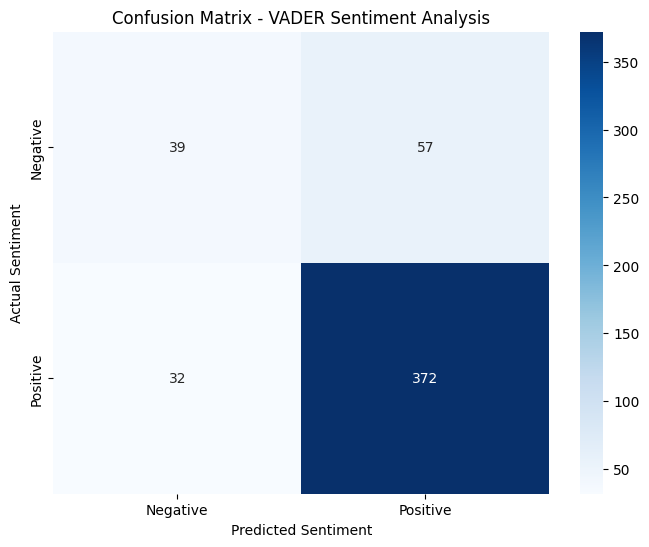

In [45]:
# Evaluate VADER sentiment analysis on the test dataset
evaluate_vader(test_data_vader)


In [46]:
# -------------------- RNN MODEL --------------------

Expand Contractions: Contractions like "don't" are expanded to "do not" to standardize the text. This step ensures that words are in their full form, which can improve the model's understanding and reduce the vocabulary size.
Handle Negations: Negations can significantly alter the sentiment of a sentence (e.g., "not happy" vs. "happy"). Handling negations explicitly helps the model capture these nuances, which is critical for sentiment analysis.
Remove HTML Tags: Tweets and other text data often contain HTML tags (especially if they are scraped from the web). Removing these tags cleans up the text and removes irrelevant information that could confuse the model.
Remove Unicode Characters: Unicode characters (e.g., special symbols or non-ASCII characters) may not be relevant to the analysis and could introduce noise. Removing them helps in maintaining a cleaner dataset.
Convert Emojis to Text: Emojis carry sentiment and meaning that should not be lost. Converting them to text descriptions (e.g., 🙂 -> "smiley face") helps the model interpret the sentiment they convey.
Remove URLs: URLs typically do not contribute to the sentiment or meaning of the tweet and can be seen as noise. Removing them focuses the model on the actual content.
Remove User Mentions: Mentions of other users (e.g., @username) are often irrelevant to the tweet's sentiment and can be removed to reduce noise in the text.
Remove Hashtags but Retain Words: Hashtags can contain important keywords (e.g., #bitcoin), but the hash symbol itself is not necessary. Removing the symbol while retaining the word keeps the relevant information intact.
Remove Numbers: Numbers may not contribute to the sentiment analysis and can be irrelevant in most contexts. Removing them simplifies the text, focusing on the words that carry meaning.
Remove Special Characters and Punctuation: Special characters and unnecessary punctuation can clutter the text and may not add value to the sentiment analysis. Removing them cleans up the text.
Normalize Repeated Characters: Repeated characters (e.g., "loooove") are often used for emphasis in informal text like tweets. Normalizing these to their base form ("love") ensures that the model treats them as a single word, improving generalization.
Convert Text to Lowercase: Converting all text to lowercase ensures consistency, so the model does not treat "Bitcoin" and "bitcoin" as different words. This step reduces vocabulary size and helps in standardizing the text.
Tokenize the Text: Tokenization splits the text into individual words or tokens, which are the basic units of analysis for the model. This step is crucial for converting text into a format that the RNN can process.
Remove Stopwords: Stopwords (e.g., "the", "and") are common words that do not contribute much to the sentiment or meaning. Removing them reduces noise and allows the model to focus on the more meaningful words.
Apply Lemmatization: Lemmatization reduces words to their base or dictionary form (e.g., "running" -> "run"). This helps in reducing the number of unique words in the text, making the model's job easier and improving its ability to generalize.
Apply Stemming: Stemming reduces words to their root form (e.g., "happiness" -> "happi"). This further simplifies the text, potentially improving the model's ability to recognize different forms of the same word.
Remove Excessive Whitespace: Excessive spaces can introduce inconsistencies in the text format. Removing them ensures a clean, uniform input for the model.

In [48]:
def preprocess_tweet_rnn(tweet):
    """
    Preprocess a tweet specifically for RNN models by performing the following steps:
    1. Expand contractions
    2. Handle negations
    3. Remove HTML tags
    4. Remove unicode characters
    5. Convert emojis to text
    6. Remove URLs
    7. Remove user mentions
    8. Remove hashtags but retain the words
    9. Remove numbers
    10. Remove special characters and punctuation
    11. Normalize repeated characters
    12. Convert text to lowercase
    13. Tokenize the text
    14. Remove stopwords
    15. Apply lemmatization
    16. Apply stemming
    17. Remove excessive whitespace
    
    Returns the cleaned tweet as a single string.
    """
    # Step 1: Expand contractions
    tweet = contractions.fix(tweet)

    # Step 2: Handle negations
    tweet = handle_negations(tweet)

    # Step 3: Remove HTML tags
    tweet = BeautifulSoup(tweet, "html.parser").get_text()

    # Step 4: Remove unicode characters
    tweet = tweet.encode('ascii', 'ignore').decode('ascii')

    # Step 5: Convert emojis to text
    tweet = emoji.demojize(tweet)

    # Step 6: Remove URLs
    tweet = re.sub(r"http\S+|www.\S+|https.\S+", '', tweet, flags=re.MULTILINE)

    # Step 7: Remove user mentions
    tweet = re.sub(r'@\w+', '', tweet)

    # Step 8: Remove hashtags but retain the words
    tweet = re.sub(r'#', '', tweet)

    # Step 9: Remove numbers
    tweet = re.sub(r'\d+', '', tweet)

    # Step 10: Remove special characters and punctuation
    tweet = re.sub(r"[@#\!\$\%\^\&\*\(\)\[\]\{\}\;:\'\"\<\>\?\,\.\~\`]", '', tweet)

    # Step 11: Normalize repeated characters
    tweet = re.sub(r'(.)\1+', r'\1\1', tweet)

    # Step 12: Convert text to lowercase
    tweet = tweet.lower()

    # Step 13: Tokenize the text
    tokens = word_tokenize(tweet)

    # Step 14: Remove stopwords
    tokens = [word for word in tokens if word.isalpha() and word not in stop_words]

    # Step 15: Apply lemmatization
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Step 16: Apply stemming
    tokens = [stemmer.stem(word) for word in tokens]

    # Step 17: Remove excessive whitespace
    tweet = " ".join(tokens).strip()

    return tweet

In [47]:
# Create a copy of the data specifically for RNN. Same as Vader, to isolate the datasets to not effect from other models
train_data_rnn = train_data.copy()
test_data_rnn = test_data.copy()

In [49]:
# Apply the preprocessing for RNN
train_data_rnn['cleaned_content_rnn'] = train_data_rnn['content'].apply(preprocess_tweet_rnn)
test_data_rnn['cleaned_content_rnn'] = test_data_rnn['content'].apply(preprocess_tweet_rnn)

C:\Users\flori\AppData\Local\Temp\ipykernel_17132\590568474.py:31: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  tweet = BeautifulSoup(tweet, "html.parser").get_text()
C:\Users\flori\AppData\Local\Temp\ipykernel_17132\590568474.py:31: MarkupResemblesLocatorWarning: The input looks more like a filename than markup. You may want to open this file and pass the filehandle into Beautiful Soup.
  tweet = BeautifulSoup(tweet, "html.parser").get_text()


In [50]:
# Display a sample of the cleaned tweets for RNN
print("\nSample of cleaned training data (RNN):")
print(train_data_rnn[['content', 'cleaned_content_rnn']].head())


Sample of cleaned training data (RNN):
                                                               content  \
tweet ID                                                                 
1641579121972236290  $Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏...   
1641579176171016194  Alright I have my rares. Who else is grabbing ...   
1641579486071390208  Bitcoin (BTC) Targets Over $100,000 as This Im...   
1641579537103302656  📢 Xverse Web-based pool is live:\n\n•Update @x...   
1641579588399804418  Yesterday, a Bitcoin projection was displayed ...   

                                                   cleaned_content_rnn  
tweet ID                                                                
1641579121972236290  bitcoin sooner think bitcointo whether believ ...  
1641579176171016194  alright rare els grab discord bit today lovin ...  
1641579486071390208  bitcoin btc target import pattern reemerg anal...  
1641579537103302656  xvers pool live updat chrome browser extens wa...  
164

In [51]:
#  Check for Empty or Near-Empty Rows in the cleaned RNN data
empty_cleaned_rows_rnn = train_data_rnn[train_data_rnn['cleaned_content_rnn'].str.strip() == ""]
print(f"Number of empty cleaned rows (RNN): {len(empty_cleaned_rows_rnn)}")
if len(empty_cleaned_rows_rnn) > 0:
    print(empty_cleaned_rows_rnn.head())
# Check for near-empty cleaned rows in RNN data
short_cleaned_rows_rnn = train_data_rnn[train_data_rnn['cleaned_content_rnn'].str.len() < 5]
print(f"Number of near-empty cleaned rows (RNN): {len(short_cleaned_rows_rnn)}")
if len(short_cleaned_rows_rnn) > 0:
    print(short_cleaned_rows_rnn.head())

Number of empty cleaned rows (RNN): 0
Number of near-empty cleaned rows (RNN): 0


In [52]:
# After preprocessing, duplicates might have been introduced or become more apparent. 
# It’s crucial to check for duplicates again to avoid redundancy in the dataset.
duplicate_cleaned_rows_rnn = train_data_rnn[train_data_rnn.duplicated(subset='cleaned_content_rnn', keep=False)]
print(f"Number of duplicate cleaned rows (RNN): {len(duplicate_cleaned_rows_rnn)}")
if len(duplicate_cleaned_rows_rnn) > 0:
    print(duplicate_cleaned_rows_rnn.head())

Number of duplicate cleaned rows (RNN): 37
                                                              hashtags  \
tweet ID                                                                 
1641581112852971524  [Solana, bitcoin, FRONK, BONK, CRYPTO, ETH, BS...   
1641581822403309568  [NFT, nfts, nft, nftart, nftcommunity, nftcoll...   
1641599616280850433  [Giveaways, ETH, NFT, NFTs, Apt, SolNFT, EGLD,...   
1641607540411645953  [Solana, bitcoin, FRONK, BONK, CRYPTO, ETH, BS...   
1641608327435264000  [NFT, nft, nftart, nfts, art, crypto, nftartis...   

                                                               content  \
tweet ID                                                                 
1641581112852971524  IBIS SACRED, new solana project. metaverse com...   
1641581822403309568  Free #NFT Giveaway🎁\n\n🚨Drop your $ETH address...   
1641599616280850433  🎁#Giveaways 🎁\n\n🏆$15 #ETH\n🏆Rekt Monkey #NFT ...   
1641607540411645953  IBIS SACRED, new solana project. metaverse com.

In [53]:
# Remove Duplicate Rows based on 'cleaned_content_rnn'
train_data_rnn = train_data_rnn.drop_duplicates(subset='cleaned_content_rnn', keep='first')

print("Number of rows after removing duplicates (RNN):", len(train_data_rnn))

Number of rows after removing duplicates (RNN): 1481


In [54]:
# After removing duplicates and filtering out short tweets, it's important to review the class distribution again
class_distribution_rnn = train_data_rnn['sentiment'].value_counts()
print("Class distribution after preprocessing for RNN:")
print(class_distribution_rnn)

Class distribution after preprocessing for RNN:
sentiment
True     1204
False     277
Name: count, dtype: int64


In [55]:
# Encode sentiment labels as 0 (negative) and 1 (positive) for RNN-specific data
train_data_rnn['sentiment'] = train_data_rnn['sentiment'].apply(lambda x: 1 if x else 0)
test_data_rnn['sentiment'] = test_data_rnn['sentiment'].apply(lambda x: 1 if x else 0)

In [56]:
# Extract features and labels for RNN-specific data
X_rnn = train_data_rnn['cleaned_content_rnn']
y_rnn = train_data_rnn['sentiment']
X_test_rnn = test_data_rnn['cleaned_content_rnn']
y_test_rnn = test_data_rnn['sentiment']

In [57]:
# Split the data into training and validation sets (80% train, 20% validation) for RNN
X_train_rnn, X_val_rnn, y_train_rnn, y_val_rnn = train_test_split(X_rnn, y_rnn, test_size=0.2, random_state=42)


In [58]:
# Tokenization and Padding for RNN-specific data
tokenizer_rnn = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer_rnn.fit_on_texts(X_train_rnn)
X_train_seq_rnn = tokenizer_rnn.texts_to_sequences(X_train_rnn)
X_val_seq_rnn = tokenizer_rnn.texts_to_sequences(X_val_rnn)
X_test_seq_rnn = tokenizer_rnn.texts_to_sequences(X_test_rnn)

max_length_rnn = 57  # This should be consistent across models
X_train_pad_rnn = pad_sequences(X_train_seq_rnn, maxlen=max_length_rnn, padding='post')
X_val_pad_rnn = pad_sequences(X_val_seq_rnn, maxlen=max_length_rnn, padding='post')
X_test_pad_rnn = pad_sequences(X_test_seq_rnn, maxlen=max_length_rnn, padding='post')

# Display a summary of shapes to verify the padding
print("Shape of X_train_pad_rnn:", X_train_pad_rnn.shape)
print("Shape of X_val_pad_rnn:", X_val_pad_rnn.shape)
print("Shape of X_test_pad_rnn:", X_test_pad_rnn.shape)

Shape of X_train_pad_rnn: (1184, 57)
Shape of X_val_pad_rnn: (297, 57)
Shape of X_test_pad_rnn: (500, 57)


In [59]:
# Apply SMOTE to the RNN-specific training data
sm = SMOTE(random_state=42)
X_train_pad_resampled_rnn, y_train_resampled_rnn = sm.fit_resample(X_train_pad_rnn, y_train_rnn)


In [60]:
# Display the class distribution before and after SMOTE for RNN-specific data
print("\nClass distribution before SMOTE (RNN):")
print(y_train_rnn.value_counts())

print("\nClass distribution after SMOTE (RNN):")
print(pd.Series(y_train_resampled_rnn).value_counts())



Class distribution before SMOTE (RNN):
sentiment
1    960
0    224
Name: count, dtype: int64

Class distribution after SMOTE (RNN):
sentiment
1    960
0    960
Name: count, dtype: int64


In [61]:
def build_and_train_rnn_model(X_train_pad_resampled_rnn, y_train_resampled_rnn, X_val_pad_rnn, y_val_rnn, tokenizer_rnn, max_length_rnn):
    """
    This function builds and trains an RNN model using a bidirectional LSTM architecture.
    
    Parameters:
    - X_train_pad_resampled_rnn: The padded and resampled training data (RNN-specific).
    - y_train_resampled_rnn: The resampled labels for training data (RNN-specific).
    - X_val_pad_rnn: The padded validation data (RNN-specific).
    - y_val_rnn: The labels for validation data (RNN-specific).
    - tokenizer_rnn: The tokenizer used to process the text data (RNN-specific).
    - max_length_rnn: The maximum length of the input sequences (RNN-specific).

    Returns:
    - model: The trained RNN model.
    - history: The history object containing training details.
    """

    # Calculate vocabulary size
    vocab_size_rnn = len(tokenizer_rnn.word_index) + 1

    # Model building and training
    model = Sequential([
        Input(shape=(max_length_rnn,)),  # Input layer

        # Embedding layer with increased dimensionality
        Embedding(input_dim=vocab_size_rnn, output_dim=128),  

        # First Bidirectional LSTM layer
        Bidirectional(LSTM(64, return_sequences=True, kernel_regularizer=l2(0.001))), 
        Dropout(0.6),  

        # Second Bidirectional LSTM layer
        Bidirectional(LSTM(32, return_sequences=False, kernel_regularizer=l2(0.001))),  
        Dropout(0.6),  

        # Dense layers
        Dense(64, activation='relu', kernel_regularizer=l2(0.001)),  # Increase Dense layer units
        Dropout(0.5),

        Dense(32, activation='relu', kernel_regularizer=l2(0.001)),  # Additional Dense layer for better learning
        Dropout(0.5),

        # Output layer
        Dense(1, activation='sigmoid')  # Output a single value for binary classification
    ])

    # Compile the model with a lower learning rate
    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=5e-5), metrics=['accuracy'])
    model.summary()

    # Set up callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=2, min_lr=1e-6)
    model_checkpoint = ModelCheckpoint(filepath='best_model_rnn.keras', save_best_only=True, monitor='val_loss', mode='min')

    # Train the model
    history = model.fit(X_train_pad_resampled_rnn, y_train_resampled_rnn, 
                        validation_data=(X_val_pad_rnn, y_val_rnn), 
                        epochs=60, 
                        batch_size=64, 
                        callbacks=[early_stopping, model_checkpoint, reduce_lr])

    # Display the training history
    print("\nTraining history:")
    print(history.history)

    return model, history

In [62]:
# Function call
model_rnn, history_rnn = build_and_train_rnn_model(X_train_pad_resampled_rnn, y_train_resampled_rnn, 
                                                   X_val_pad_rnn, y_val_rnn, tokenizer_rnn, max_length_rnn)



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 57, 128)             │         503,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 57, 128)             │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 57, 128)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 64)                  │          41,216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 649,473 (2.48 MB)

 Trainable params: 649,473 (2.48 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 15s 163ms/step - accuracy: 0.5000 - loss: 1.3911 - val_accuracy: 0.2155 - val_loss: 1.3780 - learning_rate: 5.0000e-05
Epoch 2/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - accuracy: 0.4897 - loss: 1.3727 - val_accuracy: 0.2593 - val_loss: 1.3592 - learning_rate: 5.0000e-05
Epoch 3/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 77ms/step - accuracy: 0.5191 - loss: 1.3532 - val_accuracy: 0.2492 - val_loss: 1.3413 - learning_rate: 5.0000e-05
Epoch 4/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - accuracy: 0.5296 - loss: 1.3359 - val_accuracy: 0.4545 - val_loss: 1.3234 - learning_rate: 5.0000e-05
Epoch 5/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - accuracy: 0.5168 - loss: 1.3185 - val_accuracy: 0.3030 - val_loss: 1.3074 - learning_rate: 5.0000e-05
Epoch 6/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.4976 - loss: 1.3021 - val_accuracy: 0.2997 - val_loss: 1.2912 - learning_rate: 5.0000e-05
Epoch 7/60
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.501

In [63]:
def evaluate_rnn_model(model, X_val_pad, y_val):
    """
    Evaluates the RNN model on the validation set and prints out performance metrics.
    
    Parameters:
    - model: The trained RNN model.
    - X_val_pad: Padded sequences for the validation set.
    - y_val: True labels for the validation set.
    
    Returns:
    - None
    """
    # Step 1: Predict the class labels for the validation data
    y_pred = (model.predict(X_val_pad) > 0.5).astype(int)
    
    # Step 2: Calculate accuracy
    accuracy = accuracy_score(y_val, y_pred)
    print(f"Validation Accuracy: {accuracy:.2f}")

    # Step 3: Generate Classification Report and Confusion Matrix
    print("\nClassification Report:")
    print(classification_report(y_val, y_pred, target_names=['Negative', 'Positive']))

    # Step 4: Confusion Matrix Visualization
    conf_matrix = confusion_matrix(y_val, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted Sentiment')
    plt.ylabel('Actual Sentiment')
    plt.title('Confusion Matrix - RNN Model')
    plt.show()

    # Step 5: ROC-AUC Curve
    y_pred_prob = model.predict(X_val_pad).ravel()  # Get probabilities for the positive class
    roc_auc = roc_auc_score(y_val, y_pred_prob)
    fpr, tpr, _ = roc_curve(y_val, y_pred_prob)

    plt.figure()
    plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC)')
    plt.legend(loc='lower right')
    plt.show()

10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 134ms/step
Validation Accuracy: 0.37

Classification Report:
              precision    recall  f1-score   support

    Negative       0.20      0.85      0.32        53
    Positive       0.89      0.26      0.41       244

    accuracy                           0.37       297
   macro avg       0.54      0.56      0.36       297
weighted avg       0.77      0.37      0.39       297



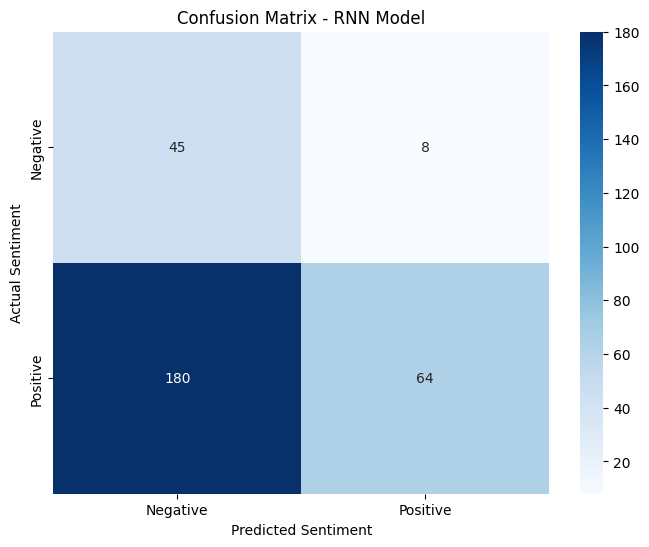

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step


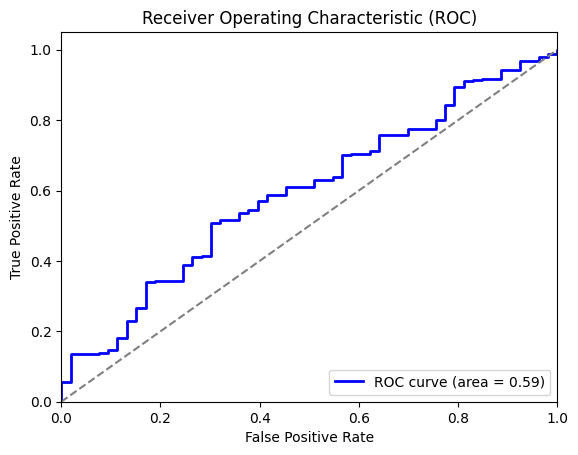

In [64]:
# Evaluation the RNN model
evaluate_rnn_model(model_rnn, X_val_pad_rnn, y_val_rnn)


In [65]:

# -------------------- DISTILBERT PRE-TRAINED MODEL --------------------

In [66]:
# Create a copy of the data specifically for DistilBERT. Same logic as Vader and RNN
train_data_distilbert = train_data.copy()
test_data_distilbert = test_data.copy()

 Some of the preprocessing point are using DistilBERT (unlike RNN), the focus is on maintaining the semantic content of the text while removing elements that do not contribute to the meaning. The preprocessing steps used here are minimal and targeted because pre-trained transformer models like DistilBERT are designed to handle a wide range of textual inputs and are already robust to many common variations in text.

In [67]:
def preprocess_text_distilbert(text):
    """
    Preprocesses text specifically for use with DistilBERT models.
    This involves:
    1. Removing HTML tags
    2. Removing URLs
    3. Removing user mentions
    4. Removing hashtags but retaining the words
    5. Converting text to lowercase

    Returns the cleaned text as a single string.
    """
    # Step 1: Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    
    # Step 2: Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    
    # Step 3: Remove user mentions
    text = re.sub(r'@\w+', '', text)
    
    # Step 4: Remove hashtags but keep the words
    text = re.sub(r'#', '', text)
    
    # Step 5: Convert to lowercase
    text = text.lower()
    
    return text

In [68]:
# Apply the preprocessing for DistilBERT
train_data_distilbert['cleaned_content_distilbert'] = train_data_distilbert['content'].apply(preprocess_text_distilbert)
test_data_distilbert['cleaned_content_distilbert'] = test_data_distilbert['content'].apply(preprocess_text_distilbert)

In [69]:
# Display the first few rows of cleaned data for verification
print("\nSample of cleaned training data for DistilBERT:")
print(train_data_distilbert[['content', 'cleaned_content_distilbert']].head())



Sample of cleaned training data for DistilBERT:
                                                               content  \
tweet ID                                                                 
1641579121972236290  $Bitcoin TO $100,000 SOONER THAN YOU THINK‼️💯🙏...   
1641579176171016194  Alright I have my rares. Who else is grabbing ...   
1641579486071390208  Bitcoin (BTC) Targets Over $100,000 as This Im...   
1641579537103302656  📢 Xverse Web-based pool is live:\n\n•Update @x...   
1641579588399804418  Yesterday, a Bitcoin projection was displayed ...   

                                            cleaned_content_distilbert  
tweet ID                                                                
1641579121972236290  $bitcoin to $100,000 sooner than you think‼️💯🙏...  
1641579176171016194  alright i have my rares. who else is grabbing ...  
1641579486071390208  bitcoin (btc) targets over $100,000 as this im...  
1641579537103302656  📢 xverse web-based pool is live:\n\n•update  c

In [104]:
# Tokenization for DistilBERT
tokenizer_distilbert = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
# Tokenize the data using the cleaned content specific to DistilBERT
train_encodings_distilbert = tokenizer_distilbert(train_data_distilbert['cleaned_content_distilbert'].tolist(), truncation=True, padding=True, max_length=57)
test_encodings_distilbert = tokenizer_distilbert(test_data_distilbert['cleaned_content_distilbert'].tolist(), truncation=True, padding=True, max_length=57)

# Extract labels
train_labels_distilbert = train_data_distilbert['sentiment'].apply(lambda x: 1 if x else 0).tolist()
test_labels_distilbert = test_data_distilbert['sentiment'].apply(lambda x: 1 if x else 0).tolist()


C:\Users\flori\anaconda3\envs\deltacourse\Lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


In [72]:
# Convert to Huggingface Dataset format
train_dataset_distilbert = Dataset.from_dict({
    'input_ids': train_encodings_distilbert['input_ids'],
    'attention_mask': train_encodings_distilbert['attention_mask'],
    'labels': train_labels_distilbert
})

test_dataset_distilbert = Dataset.from_dict({
    'input_ids': test_encodings_distilbert['input_ids'],
    'attention_mask': test_encodings_distilbert['attention_mask'],
    'labels': test_labels_distilbert
})

In [79]:
from transformers import Trainer, TrainingArguments, DistilBertForSequenceClassification

# Reload the DistilBERT model for binary classification
model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

# Set up the training arguments
training_args = TrainingArguments(
    output_dir='./results',           # Directory where the model checkpoints will be saved
    per_device_eval_batch_size=16,    # Batch size for evaluation
    logging_dir='./logs',             # Directory where logs will be saved
    logging_steps=10,                 # Number of update steps between two logs
    evaluation_strategy="steps"       # Evaluation is done at the end of every logging step
)

# Initialize the Trainer
trainer = Trainer(
    model=model,                       # The pre-trained model to evaluate
    args=training_args,                # Training arguments defined above
    eval_dataset=test_dataset_distilbert,  # The dataset to evaluate
    compute_metrics=None               # If you have any custom metrics, you can define them here
)

# Evaluate the model on the test set
eval_results = trainer.evaluate()

# Output the evaluation results
print(f"Evaluation Results: {eval_results}")


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\flori\anaconda3\envs\deltacourse\Lib\site-packages\transformers\training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Evaluation Results: {'eval_loss': 0.6830332279205322, 'eval_model_preparation_time': 0.0021, 'eval_runtime': 38.049, 'eval_samples_per_second': 13.141, 'eval_steps_per_second': 0.841}


Accuracy: 0.70
Confusion Matrix:
[[  8  88]
 [ 60 344]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.12      0.08      0.10        96
    Positive       0.80      0.85      0.82       404

    accuracy                           0.70       500
   macro avg       0.46      0.47      0.46       500
weighted avg       0.67      0.70      0.68       500



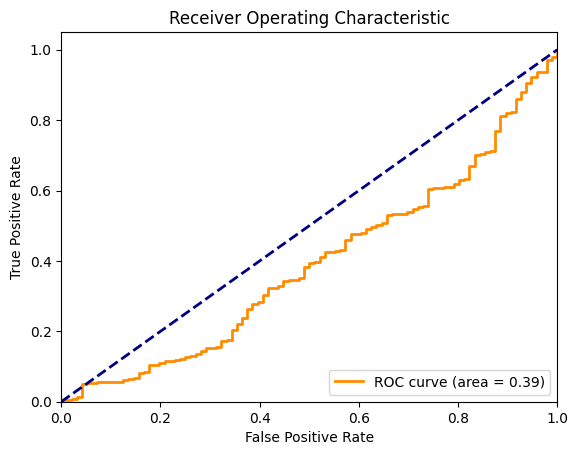

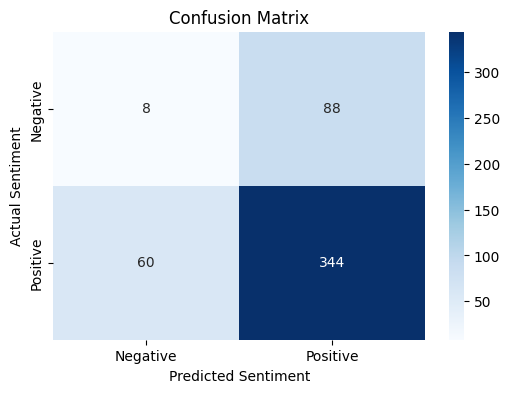

In [80]:
def evaluate_distilbert(test_dataset_distilbert, test_labels_distilbert, trainer):
    """
    This function evaluates the performance of the DistilBERT model by computing
    accuracy, precision, recall, F1-score, ROC-AUC, and plotting the confusion matrix and ROC curve.

    Args:
    test_dataset_distilbert: The test dataset to evaluate on.
    test_labels_distilbert: The true labels for the test dataset.
    trainer: The Trainer object containing the model to evaluate.
    """
    
    # Make predictions on the test dataset
    predictions = trainer.predict(test_dataset_distilbert)

    # Apply softmax to get probabilities
    probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1)

    # Get the predicted classes based on the highest probability
    preds = torch.argmax(probs, dim=1).numpy()

    # Calculate the accuracy
    accuracy = accuracy_score(test_labels_distilbert, preds)
    print(f"Accuracy: {accuracy:.2f}")

    # Calculate the confusion matrix
    cm = confusion_matrix(test_labels_distilbert, preds)
    print("Confusion Matrix:")
    print(cm)

    # Print the classification report (includes precision, recall, F1 score)
    report = classification_report(test_labels_distilbert, preds, target_names=["Negative", "Positive"])
    print("\nClassification Report:")
    print(report)

    # Compute the ROC curve and AUC based on the probability for the positive class
    fpr, tpr, _ = roc_curve(test_labels_distilbert, probs[:, 1].numpy())
    roc_auc = roc_auc_score(test_labels_distilbert, probs[:, 1].numpy())

    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    # Visualize the confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.xlabel('Predicted Sentiment')
    plt.ylabel('Actual Sentiment')
    plt.title('Confusion Matrix')
    plt.show()

# Example of how to call this function after training
evaluate_distilbert(test_dataset_distilbert, test_labels_distilbert, trainer)


In [81]:
# Fine Tuning Script
from transformers import DistilBertForSequenceClassification, Trainer, TrainingArguments
import torch

def fine_tune_distilbert(train_dataset_distilbert, test_dataset_distilbert):
    """
    Function to fine-tune a pre-trained DistilBERT model on a given training dataset
    and evaluate it on a test dataset.

    Args:
        train_dataset_distilbert: The preprocessed and tokenized training dataset.
        test_dataset_distilbert: The preprocessed and tokenized test dataset.

    Returns:
        trainer: The Trainer object used for fine-tuning.
        eval_results: The evaluation results after fine-tuning.
    """
    
    # Load the DistilBERT model for binary classification (positive/negative sentiment)
    model = DistilBertForSequenceClassification.from_pretrained('distilbert-base-uncased', num_labels=2)

    # If you have a GPU, move the model to the GPU
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Define the training arguments for fine-tuning
    training_args = TrainingArguments(
        output_dir='./results',          # Output directory for model predictions and checkpoints
        num_train_epochs=1,              # Only 1 epoch because fine-tuning can be computationally expensive
        per_device_train_batch_size=16,  # Batch size for training
        per_device_eval_batch_size=16,   # Batch size for evaluation
        warmup_steps=500,                # Number of warmup steps for learning rate scheduler
        weight_decay=0.01,               # Strength of weight decay
        logging_dir='./logs',            # Directory for storing logs
        logging_steps=10,                # Log every 10 steps
        evaluation_strategy="epoch",     # Evaluate at the end of every epoch
        save_strategy="epoch",           # Save the model at the end of every epoch
        save_total_limit=1,              # Only keep the last checkpoint
        load_best_model_at_end=True,     # Load the best model found during training at the end
        report_to="none"                 # Disable report to avoid extensive logging
    )

    # Initialize the Trainer with the model, training arguments, and datasets
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset_distilbert,
        eval_dataset=test_dataset_distilbert
    )

    # Fine-tune the model
    trainer.train()

    # Evaluate the model after fine-tuning
    eval_results = trainer.evaluate()

    print(f"Evaluation Results after Fine-Tuning: {eval_results}")
    return trainer, eval_results

# Example of how to call this function using train_dataset_distilbert and test_dataset_distilbert
trainer_fine_tune, fine_tune_results = fine_tune_distilbert(train_dataset_distilbert, test_dataset_distilbert)


Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
C:\Users\flori\anaconda3\envs\deltacourse\Lib\site-packages\transformers\training_args.py:1525: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss
1,0.404700,0.437686


Evaluation Results after Fine-Tuning: {'eval_loss': 0.43768560886383057, 'eval_runtime': 37.8001, 'eval_samples_per_second': 13.227, 'eval_steps_per_second': 0.847, 'epoch': 1.0}


Accuracy: 0.81
Confusion Matrix:
[[  0  96]
 [  0 404]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.00      0.00      0.00        96
    Positive       0.81      1.00      0.89       404

    accuracy                           0.81       500
   macro avg       0.40      0.50      0.45       500
weighted avg       0.65      0.81      0.72       500



C:\Users\flori\anaconda3\envs\deltacourse\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\flori\anaconda3\envs\deltacourse\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\flori\anaconda3\envs\deltacourse\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

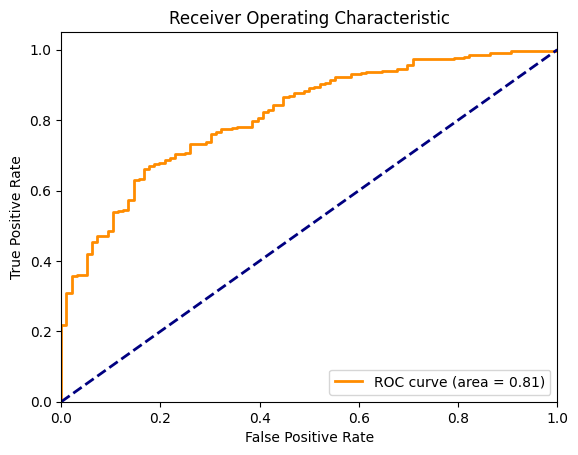

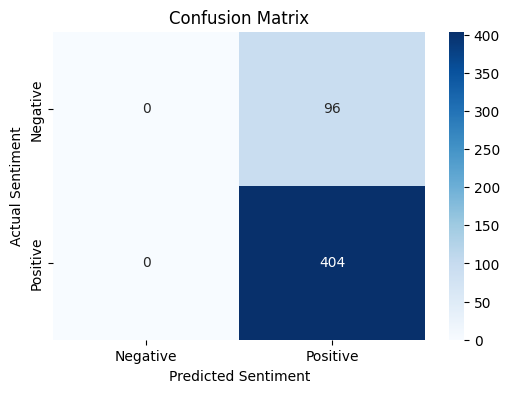

In [88]:
def evaluate_fine_tune(test_dataset_distilbert, test_labels_distilbert, trainer):
    """
    This function evaluates the performance of the DistilBERT model by computing
    accuracy, precision, recall, F1-score, ROC-AUC, and plotting the confusion matrix and ROC curve.

    Args:
    test_dataset_distilbert: The test dataset to evaluate on.
    test_labels: The true labels for the test dataset.
    trainer: The Trainer object containing the model to evaluate.
    """
    
    # Make predictions on the test dataset
    predictions = trainer.predict(test_dataset_distilbert)

    # Apply softmax to get probabilities
    probs = torch.softmax(torch.tensor(predictions.predictions), dim=-1)

    # Get the predicted classes based on the highest probability
    preds = torch.argmax(probs, dim=1).numpy()

    # Calculate the accuracy
    accuracy = accuracy_score(test_labels_distilbert, preds)
    print(f"Accuracy: {accuracy:.2f}")

    # Calculate the confusion matrix
    cm = confusion_matrix(test_labels_distilbert, preds)
    print("Confusion Matrix:")
    print(cm)

    # Print the classification report (includes precision, recall, F1 score)
    report = classification_report(test_labels_distilbert, preds, target_names=["Negative", "Positive"])
    print("\nClassification Report:")
    print(report)

    # Compute the ROC curve and AUC based on the probability for the positive class
    fpr, tpr, _ = roc_curve(test_labels_distilbert, probs[:, 1].numpy())
    roc_auc = roc_auc_score(test_labels_distilbert, probs[:, 1].numpy())

    # Plot the ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic')
    plt.legend(loc="lower right")
    plt.show()

    # Visualize the confusion matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.xlabel('Predicted Sentiment')
    plt.ylabel('Actual Sentiment')
    plt.title('Confusion Matrix')
    plt.show()

# Example of how to call this function after training
evaluate_fine_tune(test_dataset_distilbert, test_labels_distilbert, trainer_fine_tune)

In [89]:
 # Run All Evaluations and Collect Predictions
# Vader
y_true_vader = test_data_vader['sentiment']
y_pred_vader = test_data_vader['vader_sentiment']
# RNN
y_pred_rnn = (model_rnn.predict(X_test_pad_rnn) > 0.5).astype(int).flatten()
y_true_rnn = y_test_rnn
# Pre-trained DistilBERT
predictions_distilbert = trainer.predict(test_dataset_distilbert)
y_pred_distilbert = torch.argmax(torch.softmax(torch.tensor(predictions_distilbert.predictions), dim=-1), dim=1).numpy()
y_true_distilbert = test_labels_distilbert
# Fine-tuned DistilBERT
predictions_fine_tuned = trainer_fine_tune.predict(test_dataset_distilbert)
y_pred_fine_tuned = torch.argmax(torch.softmax(torch.tensor(predictions_fine_tuned.predictions), dim=-1), dim=1).numpy()
y_true_fine_tuned = test_labels_distilbert


16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step


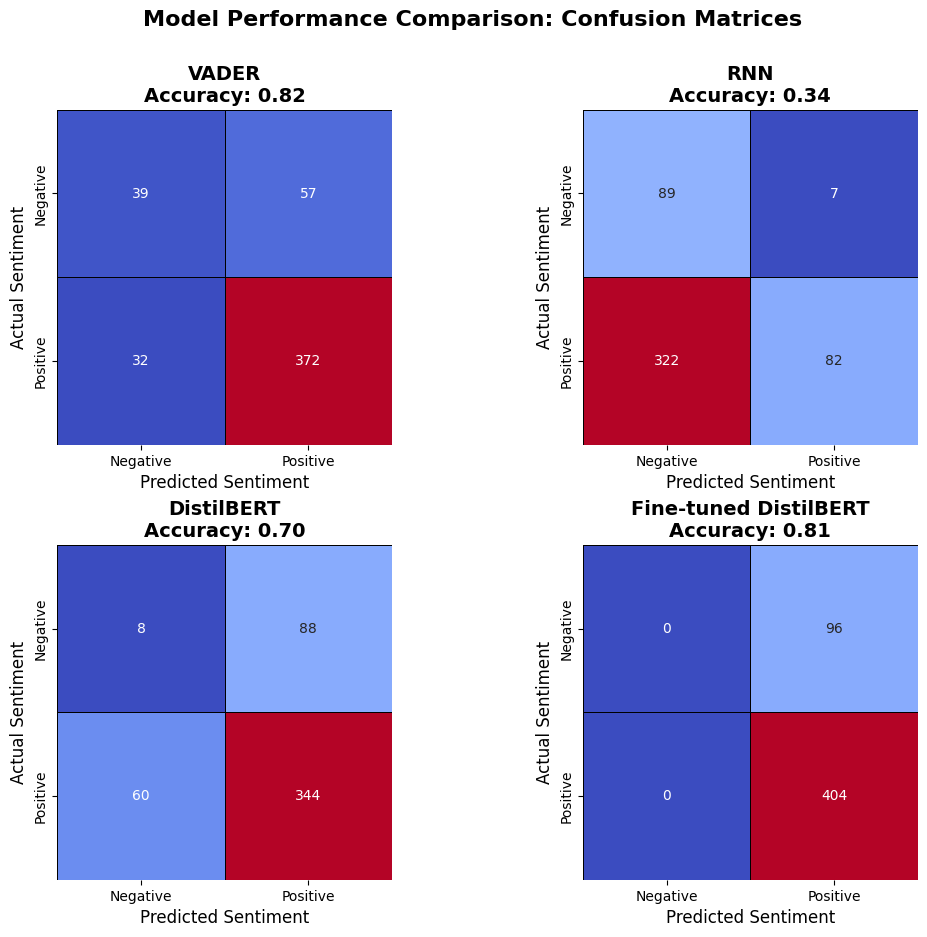

In [97]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Define the Comparison Function
def compare_models(y_true_vader, y_pred_vader, 
                   y_true_rnn, y_pred_rnn, 
                   y_true_distilbert, y_pred_distilbert,
                   y_true_fine_tuned, y_pred_fine_tuned):
    """
    Compare the performance of different models by displaying their accuracy and confusion matrices in a 2x2 grid.

    Args:
    - y_true_vader: True labels for VADER.
    - y_pred_vader: Predicted labels from VADER.
    - y_true_rnn: True labels for RNN.
    - y_pred_rnn: Predicted labels from RNN.
    - y_true_distilbert: True labels for DistilBERT.
    - y_pred_distilbert: Predicted labels from DistilBERT.
    - y_true_fine_tuned: True labels for Fine-tuned DistilBERT.
    - y_pred_fine_tuned: Predicted labels from Fine-tuned DistilBERT.
    """
    
    models = {
        "VADER": (y_true_vader, y_pred_vader),
        "RNN": (y_true_rnn, y_pred_rnn),
        "DistilBERT": (y_true_distilbert, y_pred_distilbert),
        "Fine-tuned DistilBERT": (y_true_fine_tuned, y_pred_fine_tuned)
    }

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))  # Create a 2x2 grid of subplots with a larger size

    for ax, (model_name, (y_true, y_pred)) in zip(axes.flatten(), models.items()):
        accuracy = accuracy_score(y_true, y_pred)
        cm = confusion_matrix(y_true, y_pred)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap='coolwarm', ax=ax, 
                    xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'], 
                    cbar=False, linewidths=0.5, linecolor='black', square=True)
        
        ax.set_xlabel('Predicted Sentiment', fontsize=12)
        ax.set_ylabel('Actual Sentiment', fontsize=12)
        ax.set_title(f'{model_name}\nAccuracy: {accuracy:.2f}', fontsize=14, fontweight='bold')

    # Improve spacing and layout
    plt.subplots_adjust(hspace=0.3, wspace=0.3)
    plt.suptitle('Model Performance Comparison: Confusion Matrices', fontsize=16, fontweight='bold')
    plt.show()

# Assuming you've obtained all the predictions and true labels
compare_models(y_true_vader, y_pred_vader, 
               y_true_rnn, y_pred_rnn, 
               y_true_distilbert, y_pred_distilbert,
               y_true_fine_tuned, y_pred_fine_tuned)


## Interpretation of the model/  Computational essay
Sentiment analysis is crucial in understanding public opinions, particularly in social media like Twitter. Using a dataset of tweets on Bitcoin, this study compares and assesses four different sentiment analysis techniques: RNN model, pre-trained DistilBERT, fine-tuned DistilBERT, and sentiment dictionary (VADER).

Each approach is analyzed in terms of implementation, preprocessesing, cleaning dataset, training processes, performance metrics, and comparison between model.

Approach 1: Sentiment dictionary (VADER Sentiment Analysis)
Implementation: VADER is a sentiment analysis tool for social media material that is rule-based. Without requiring a lot of processing power, it classifies text sentiment using rules and a lexicon.
Training Process: Because VADER uses a preset language to function, it doesn't require training.
Metrics and Performance: 
* Accuracy: 0.82  
* Confusion Matrix: VADER accurately captures positive sentiments but struggles with negatives.

Conclusion: VADER is an efficient and straightforward approach for sentiment analysis, making it ideal for applications requiring quick results with limited computational power. However, it has limitations in handling complex linguistic structures.

Approach 2: Recurrent Neural Network (RNN)
Implementation: The RNN model was built using a bidirectional LSTM architecture to capture the sequential dependencies in the text.
Training Process: The model was trained on padded sequences of tokenized tweets, to remove duplicate text after preprocessing,  apply SMOTE to address class imbalance. Despite using techniques like early stopping to prevent overfitting, the model underperformed.
Metrics and Performance:
* Confusion Matrix: Significant misclassifications, particularly with positive sentiments.

Conclusion:The RNN model struggled with class imbalance and overfitting, resulting in poor generalization. This underscores the need for careful model selection and tuning in real-world text analysis.

Approach 3: Pre-trained DistilBERT
Implementation: DistilBERT, a lightweight version of BERT, was used in its pre-trained form without any additional training, leveraging its robust contextual understanding for sentiment analysis
Training Process: The pre-trained model was directly evaluated on the test set, without further fine-tuning..
Metrics and Performance:
* Accuracy: 0.70
* Confusion Matrix: Shows moderate performance, with some errors in classifying both positive and negative sentiments.

Conclusion: The pre-trained DistilBERT model demonstrates the effectiveness of transformer models in NLP tasks. While it outperformed the RNN, its performance could be enhanced through fine-tuning, especially for domain-specific tasks.

Approach 4: Fine-tuned DistilBERT
Implementation: The DistilBERT model was fine-tuned on the Bitcoin tweet dataset to adapt it to the specific characteristics of the domain.
Training Process: Fine-tuning was performed with one epoch to prevent overfitting, optimizing the model's weights based on the training data.
Metrics and Performance:
* Accuracy: 0.81
* Confusion Matrix: Significant improvement over the pre-trained model, with fewer misclassifications.

Conclusion: Fine-tuning significantly improved the DistilBERT model's performance, making it the most effective approach in this study. It balances computational efficiency with deep learning's ability to capture nuanced sentiment, making it the most versatile option.

Overall Conclusion:
This computational essay demonstrates that different sentiment analysis approaches offer various strengths and weaknesses. VADER is suitable for quick, resource-efficient analysis, while RNNs highlight the challenges of deep learning with complexity and overfitting. DistilBERT models, particularly when fine-tuned, offer a powerful balance of efficiency and accuracy, making them highly effective for domain-specific sentiment analysis tasks. The choice of model should be guided by the specific requirements of the task, such as the need for interpretability, computational resources, and the complexity of the sentiment being analyzed. In my models, Vader and Fine Tuning work better, with a high accuracy, but Fine-Tuning has also a large ROC-value.



In [3]:
pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
